### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [4]:
from imblearn.over_sampling import RandomOverSampler
from feature_engine.selection import SmartCorrelatedSelection
from xgboost import XGBClassifier

### Step 2: Load Data

In [5]:
df = pd.read_csv('./data/AutismPrediction.csv')

In [6]:
df.shape

(800, 22)

In [7]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


### Step 3: Exploaring Data

Basic Info

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,800.0,400.500000,231.084400,1.000000,200.750000,400.500000,600.250000,800.000000
A1_Score,800.0,0.560000,0.496697,0.000000,0.000000,1.000000,1.000000,1.000000
A2_Score,800.0,0.530000,0.499411,0.000000,0.000000,1.000000,1.000000,1.000000
A3_Score,800.0,0.450000,0.497805,0.000000,0.000000,0.000000,1.000000,1.000000
A4_Score,800.0,0.415000,0.493030,0.000000,0.000000,0.000000,1.000000,1.000000
A5_Score,800.0,0.395000,0.489157,0.000000,0.000000,0.000000,1.000000,1.000000
A6_Score,800.0,0.303750,0.460164,0.000000,0.000000,0.000000,1.000000,1.000000
A7_Score,800.0,0.397500,0.489687,0.000000,0.000000,0.000000,1.000000,1.000000
A8_Score,800.0,0.508750,0.500236,0.000000,0.000000,1.000000,1.000000,1.000000
A9_Score,800.0,0.495000,0.500288,0.000000,0.000000,0.000000,1.000000,1.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [10]:
pd.DataFrame({'Null': df.isnull().sum(), 'Unique': df.nunique()})

,Null,Unique
ID,0,800
A1_Score,0,2
A2_Score,0,2
A3_Score,0,2
A4_Score,0,2
A5_Score,0,2
A6_Score,0,2
A7_Score,0,2
A8_Score,0,2
A9_Score,0,2


Target Distribution

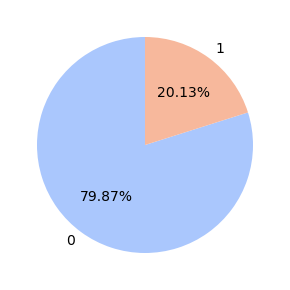

In [11]:
plt.figure(figsize=(3, 3))
plt.pie(
    df['Class/ASD'].value_counts(),
    autopct='%.2f%%',
    colors=sns.color_palette('coolwarm', 2),
    startangle=90,
    labels=df['Class/ASD'].value_counts().index
)
plt.tight_layout()

Int Distribution

In [12]:
int_cols = df.select_dtypes(np.int64).columns.to_list()

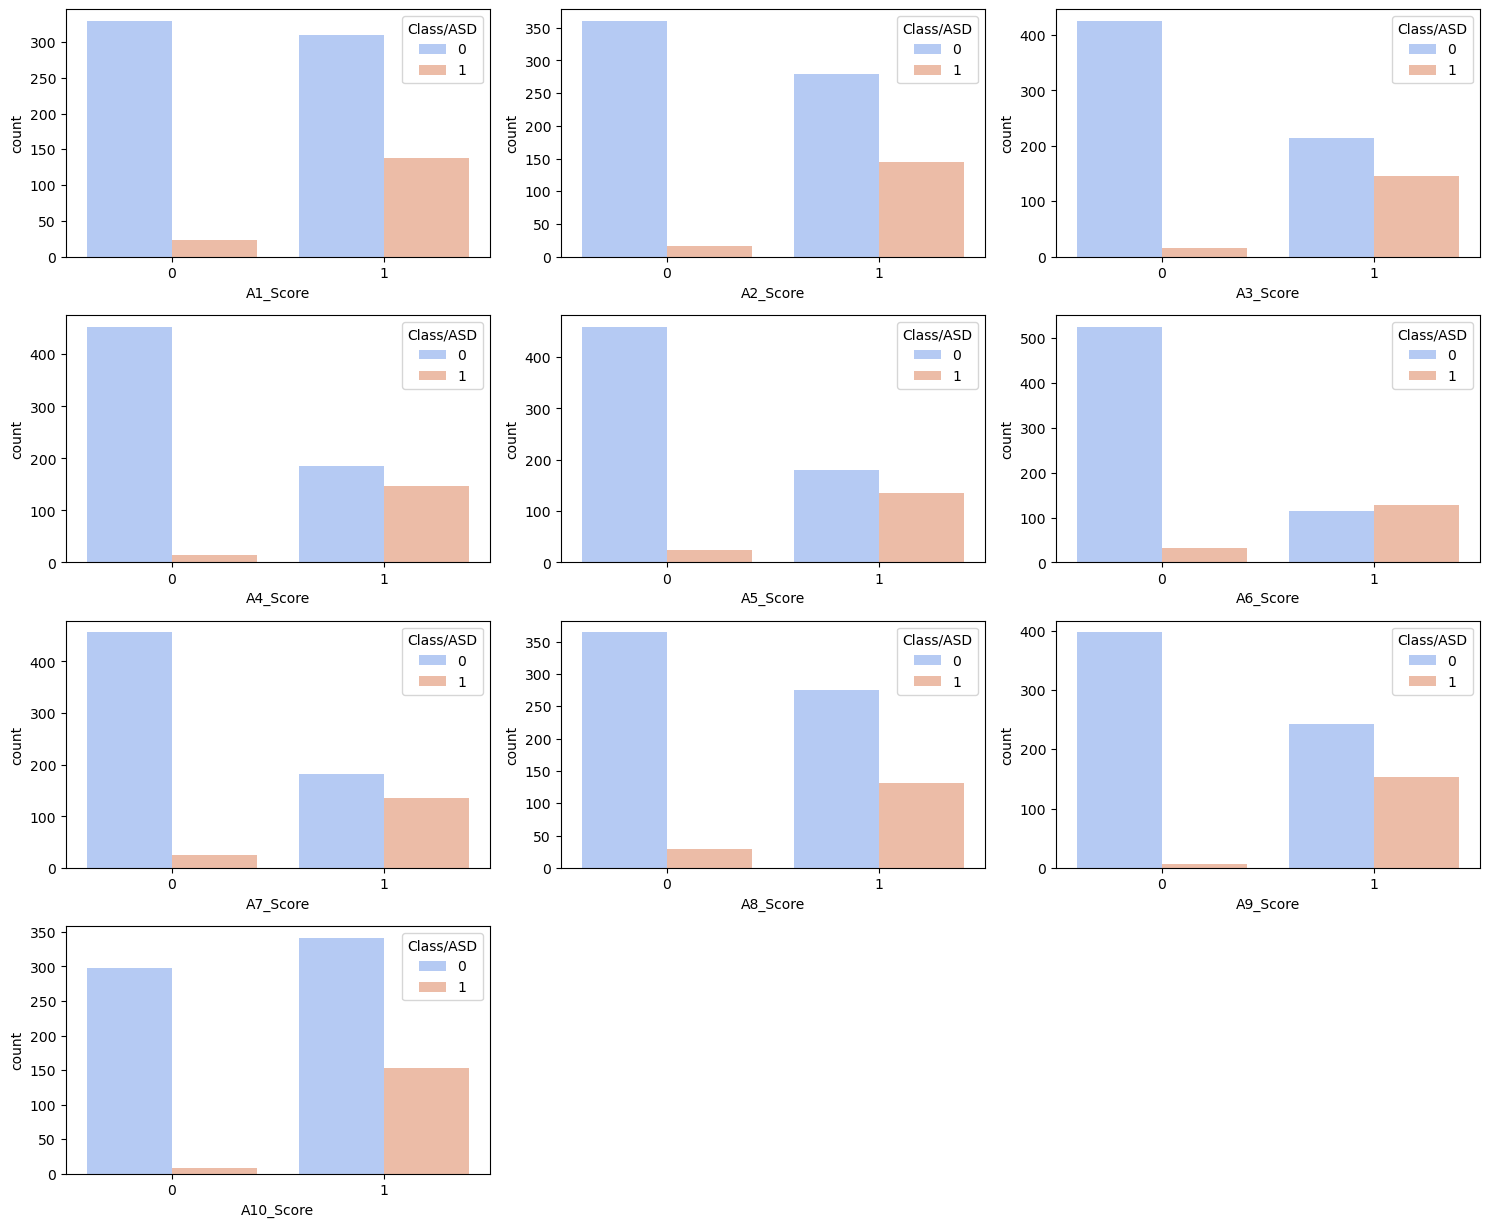

In [13]:
plt.figure(figsize=(15, 15))

for i, col in enumerate(int_cols[1:-1]):
    plt.subplot(5, 3, i+1)
    sns.countplot(x=col, hue='Class/ASD', data=df, palette='coolwarm')
plt.tight_layout()

Object Distribution

In [14]:
obj_cols = df.select_dtypes(np.object_).columns.to_list()

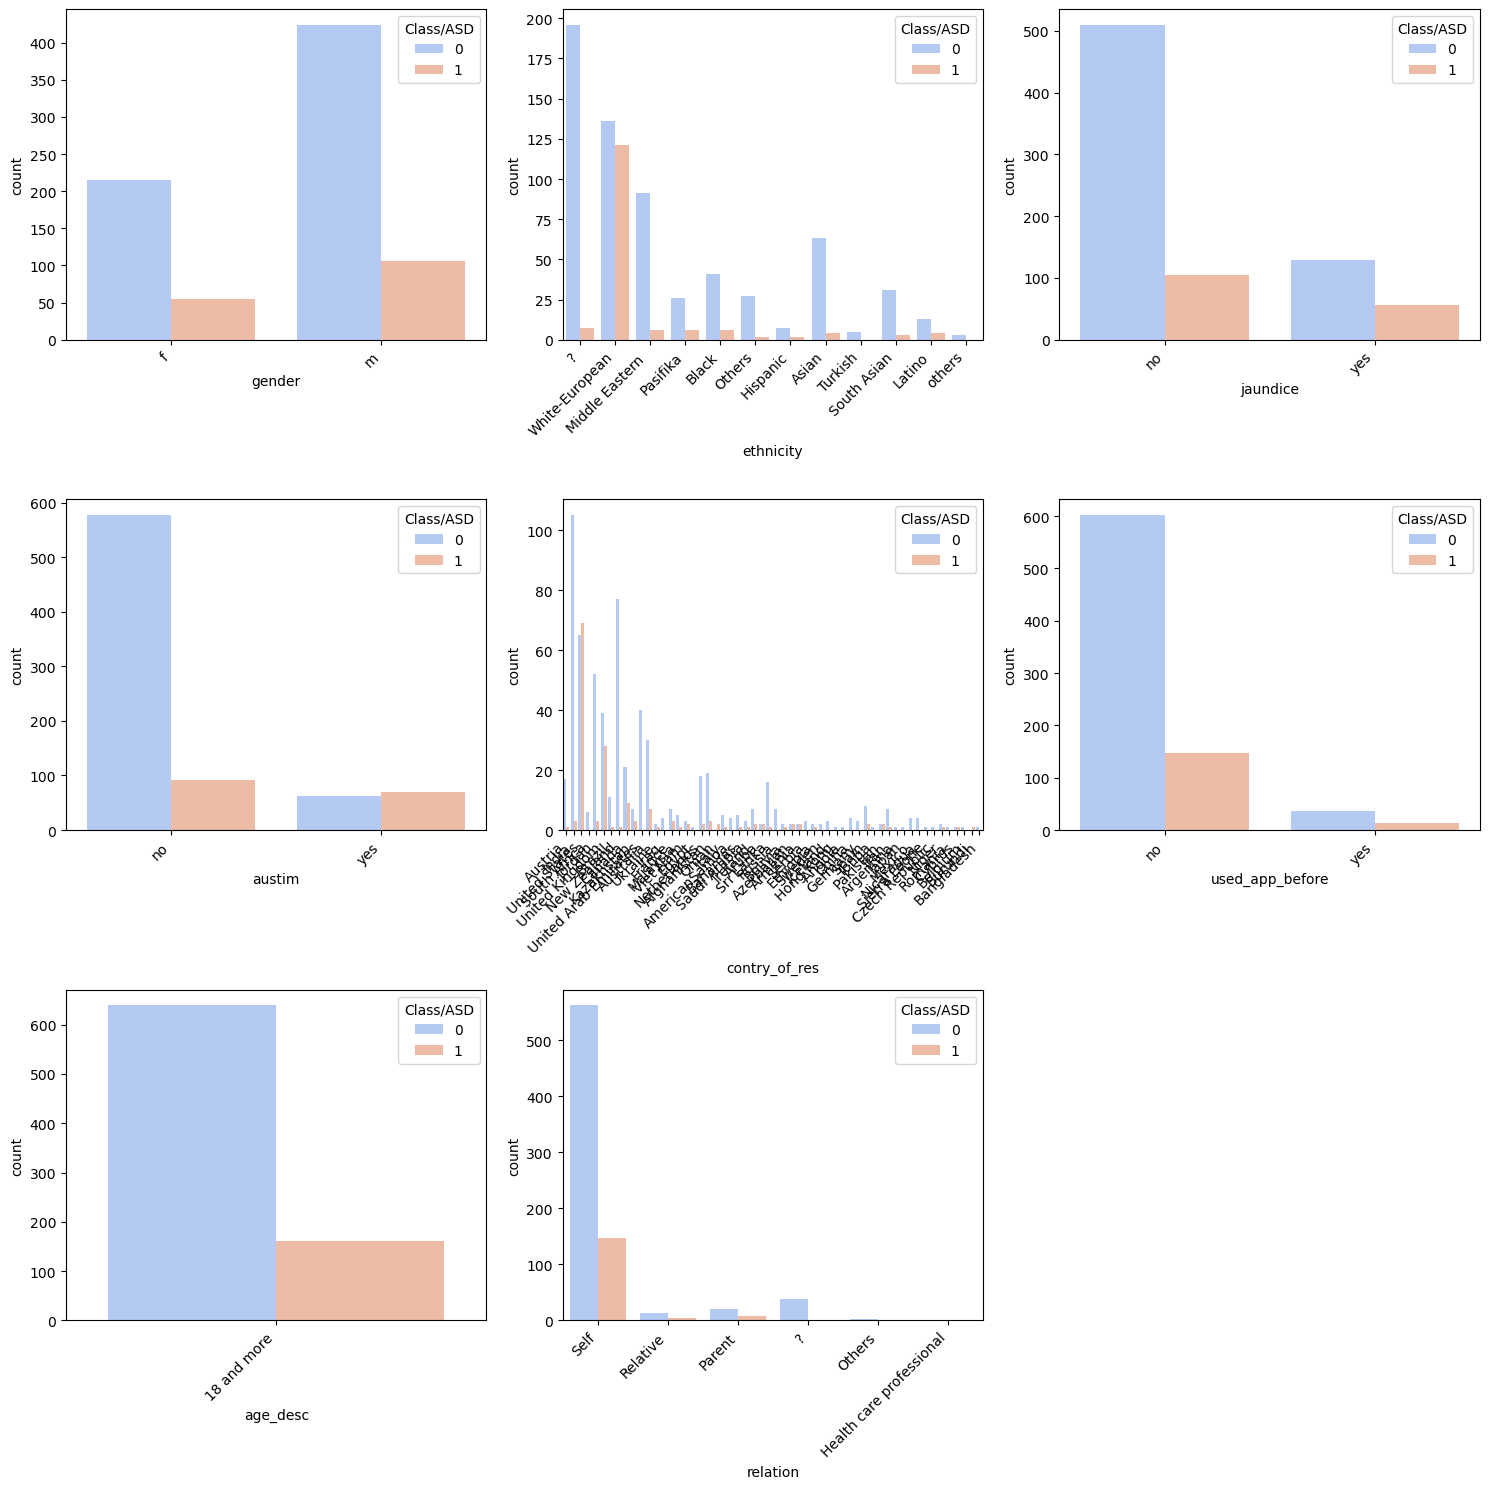

In [15]:
plt.figure(figsize=(15, 15))

for i, col in enumerate(obj_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=col, hue='Class/ASD', data=df, palette='coolwarm')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()

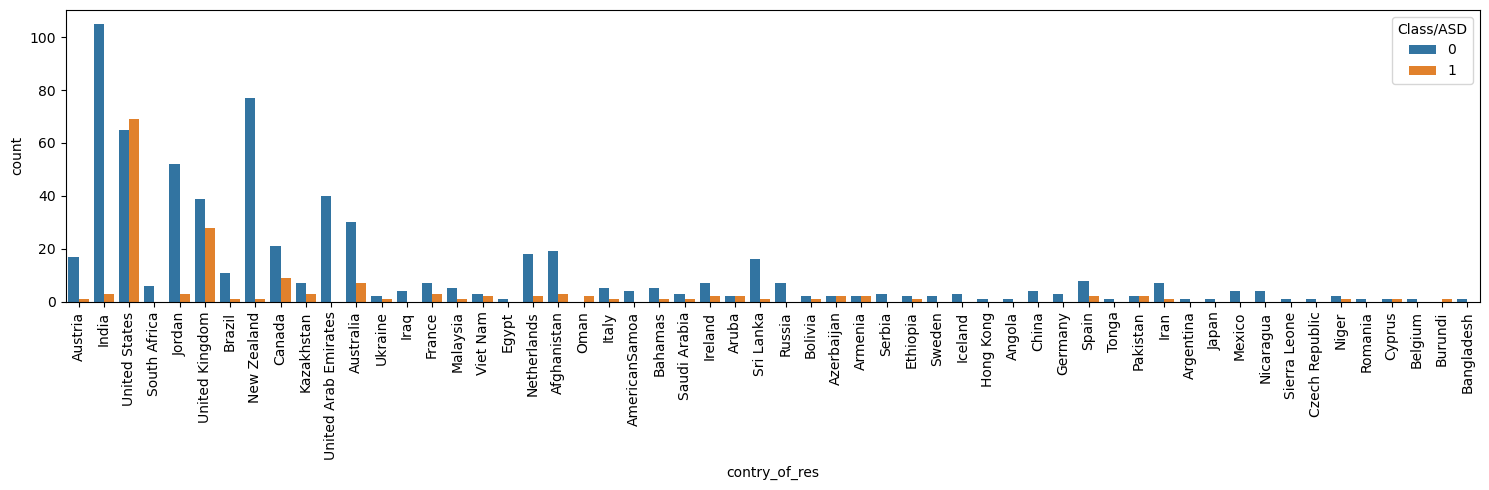

In [16]:
plt.figure(figsize=(15,5))
sns.countplot(data=df, x='contry_of_res', hue='Class/ASD')
plt.xticks(rotation=90)
plt.tight_layout()

Float Distribution

In [17]:
float_cols = df.select_dtypes(np.float64).columns.to_list()

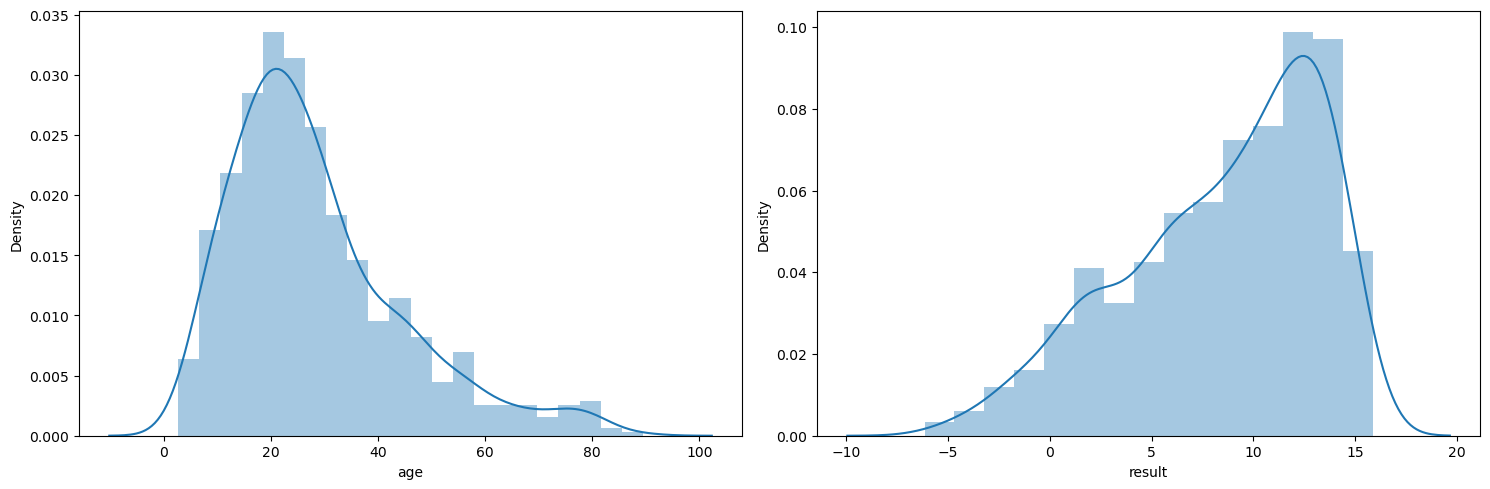

In [18]:
plt.figure(figsize=(15,5))

for i, col in enumerate(float_cols):
  plt.subplot(1,2,i+1)
  sns.distplot(df[col])
plt.tight_layout()

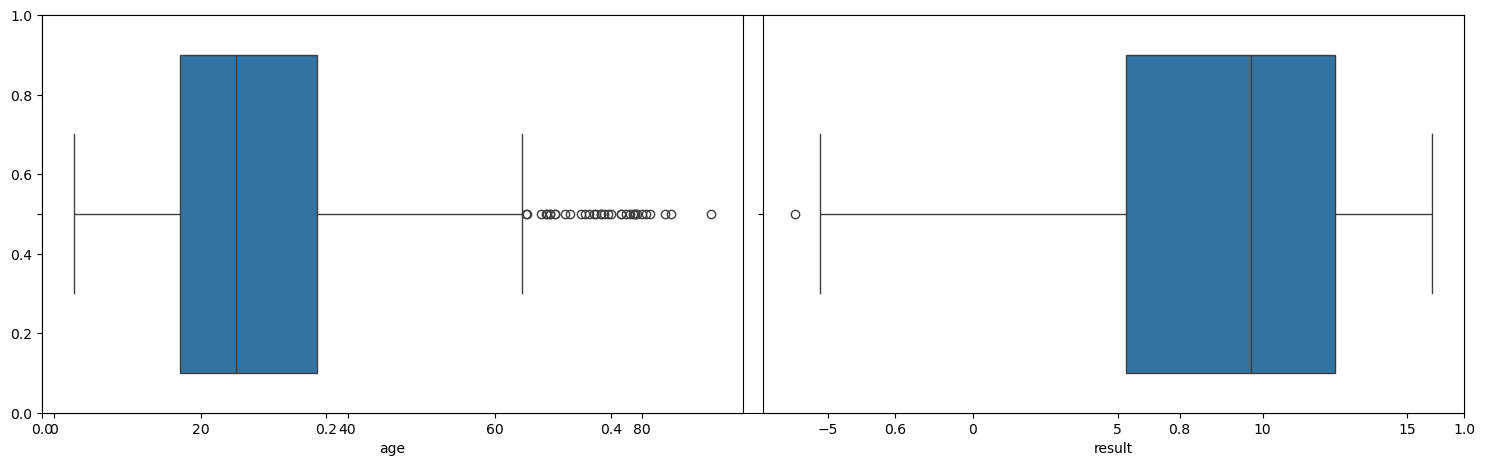

In [19]:
plt.subplots(figsize=(15,5))

for i, col in enumerate(float_cols):
  plt.subplot(1,2,i+1)
  sns.boxplot(df[col], orient='h')
plt.tight_layout()

### Step 4: Feature Engineering

Handling Missing Value

In [20]:
df.replace({'?': 'Others', 'others': 'Others'}, inplace=True)

In [21]:
df = df[df['result'] > -5]

Numerical to Categorical

In [22]:
def convertAge(age):
    if age < 4:
        return 'Toddler'
    elif age < 12:
        return 'Kid'
    elif age < 18:
        return 'Teenager'
    elif age < 40:
        return 'Young'
    else:
        return 'Senior'

In [23]:
df['ageGroup'] = df['age'].apply(convertAge)

In [24]:
obj_cols.append('ageGroup')

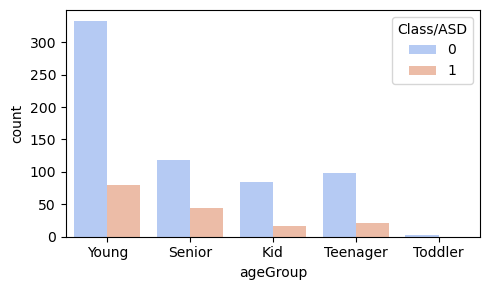

In [25]:
plt.figure(figsize=(5, 3))
sns.countplot(x='ageGroup', hue='Class/ASD', data=df, palette='coolwarm')
plt.tight_layout()

In [26]:
df['age'] = np.log(df['age'])

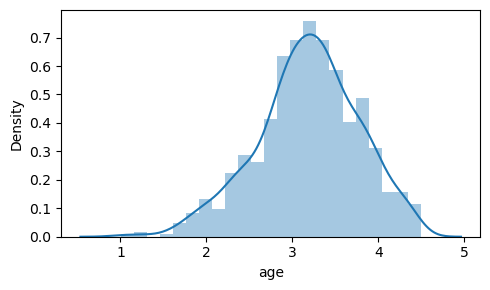

In [27]:
plt.figure(figsize=(5, 3))
sns.distplot(df['age'])
plt.tight_layout()

Create Feature

In [28]:
df['sum_score'] = 0

In [29]:
for col in int_cols[1:-1]:
    df['sum_score'] += df[col]

In [31]:
int_cols.append('sum_score')

In [32]:
df['ind'] = df['austim'] + df['used_app_before'] + df['jaundice']
obj_cols.append('ind')

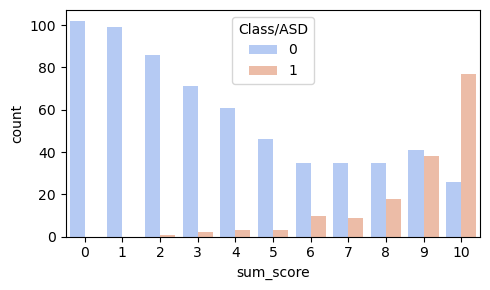

In [33]:
plt.figure(figsize=(5, 3))
sns.countplot(x='sum_score', hue='Class/ASD', data=df, palette='coolwarm')
plt.tight_layout()

Feature Encoding

In [34]:
for col in obj_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

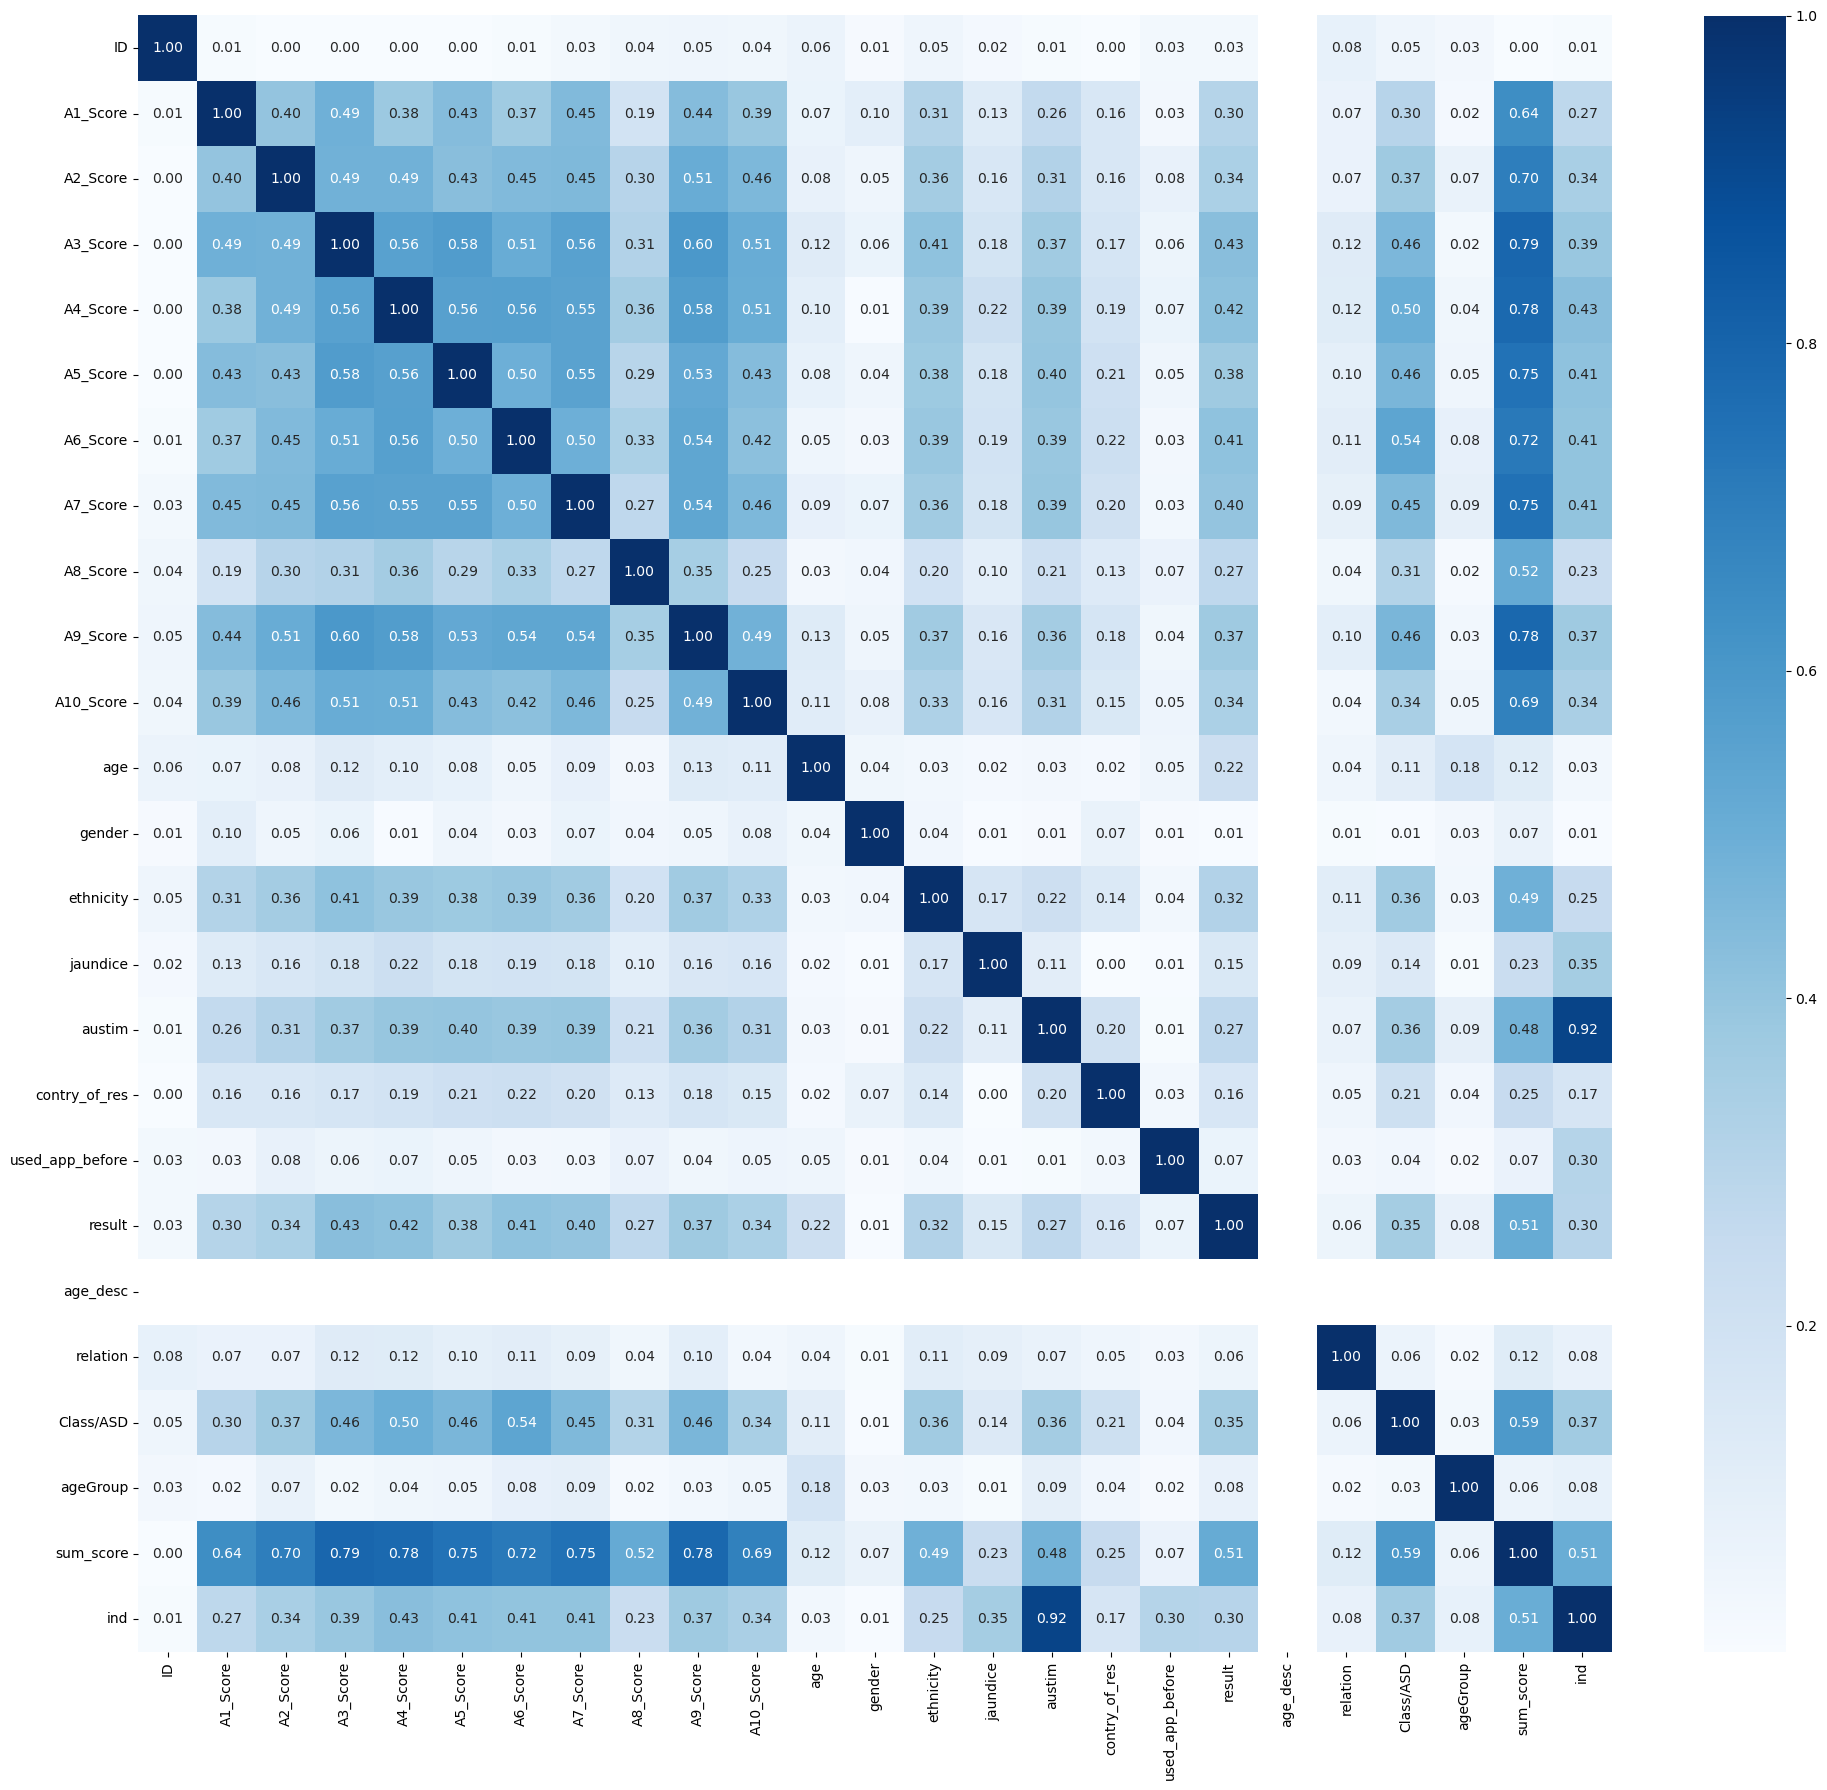

In [36]:
plt.figure(figsize=(20, 18))
sns.heatmap(
    df.corr().abs(),
    annot=True,
    fmt='.2f',
    cmap=plt.cm.Blues
)
plt.tight_layout()

### Step 5: Preparing Data

Select Features

In [37]:
features = df.drop(['ID', 'age_desc', 'Class/ASD'], axis=1)
target = df['Class/ASD']

In [38]:
selector = SmartCorrelatedSelection(
    threshold=0.8,
    selection_method='corr_with_target'
)

In [39]:
features = selector.fit_transform(features, target)
print(f'Current Number of Features is {features.shape[1]}')

Current Number of Features is 21


Split Data

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

Balance Data

In [41]:
ros = RandomOverSampler(sampling_strategy='minority',random_state=42)

In [42]:
X_train, y_train = ros.fit_resample(X_train, y_train)

Normalization

In [43]:
scaler = StandardScaler()

In [44]:
X_train = scaler.fit_transform(X_train)

In [45]:
X_test = scaler.transform(X_test)

### Step 6: Building & Training Model

In [46]:
models = [
    LogisticRegression(),
    XGBClassifier(),
    SVC()
]

In [47]:
strat = StratifiedKFold(shuffle=True, random_state=42)

In [48]:
for model in models:
    print(f'Model: {model.__class__.__name__}')
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring='accuracy',
        cv=strat,
        n_jobs=-1,
        error_score='raise'
    )
    print(f'Scores: {list(map(lambda x: round(x, 3), scores))}')
    print(f'Mean Accuracy: {scores.mean():.3f}')
    print('-' * 20)

Model: LogisticRegression
Scores: [0.796, 0.845, 0.864, 0.785, 0.844]
Mean Accuracy: 0.827
--------------------
Model: XGBClassifier
Scores: [0.922, 0.966, 0.951, 0.917, 0.961]
Mean Accuracy: 0.944
--------------------
Model: SVC
Scores: [0.869, 0.903, 0.922, 0.863, 0.927]
Mean Accuracy: 0.897
--------------------


In [49]:
for model in models:
    model.fit(X_train, y_train)    

### Step 7: Evaluate Model

In [50]:
for model in models:
    y_pred = model.predict(X_test)
    print(f'Model: {model.__class__.__name__}')
    print('Training Accuracy : ', round(metrics.roc_auc_score(y_train, model.predict(X_train)), 3))
    print('Validation Accuracy : ', round(metrics.roc_auc_score(y_test, y_pred), 3))
    print('-' * 20)

Model: LogisticRegression
Training Accuracy :  0.853
Validation Accuracy :  0.774
--------------------
Model: XGBClassifier
Training Accuracy :  1.0
Validation Accuracy :  0.751
--------------------
Model: SVC
Training Accuracy :  0.938
Validation Accuracy :  0.834
--------------------


Confusion Matrix

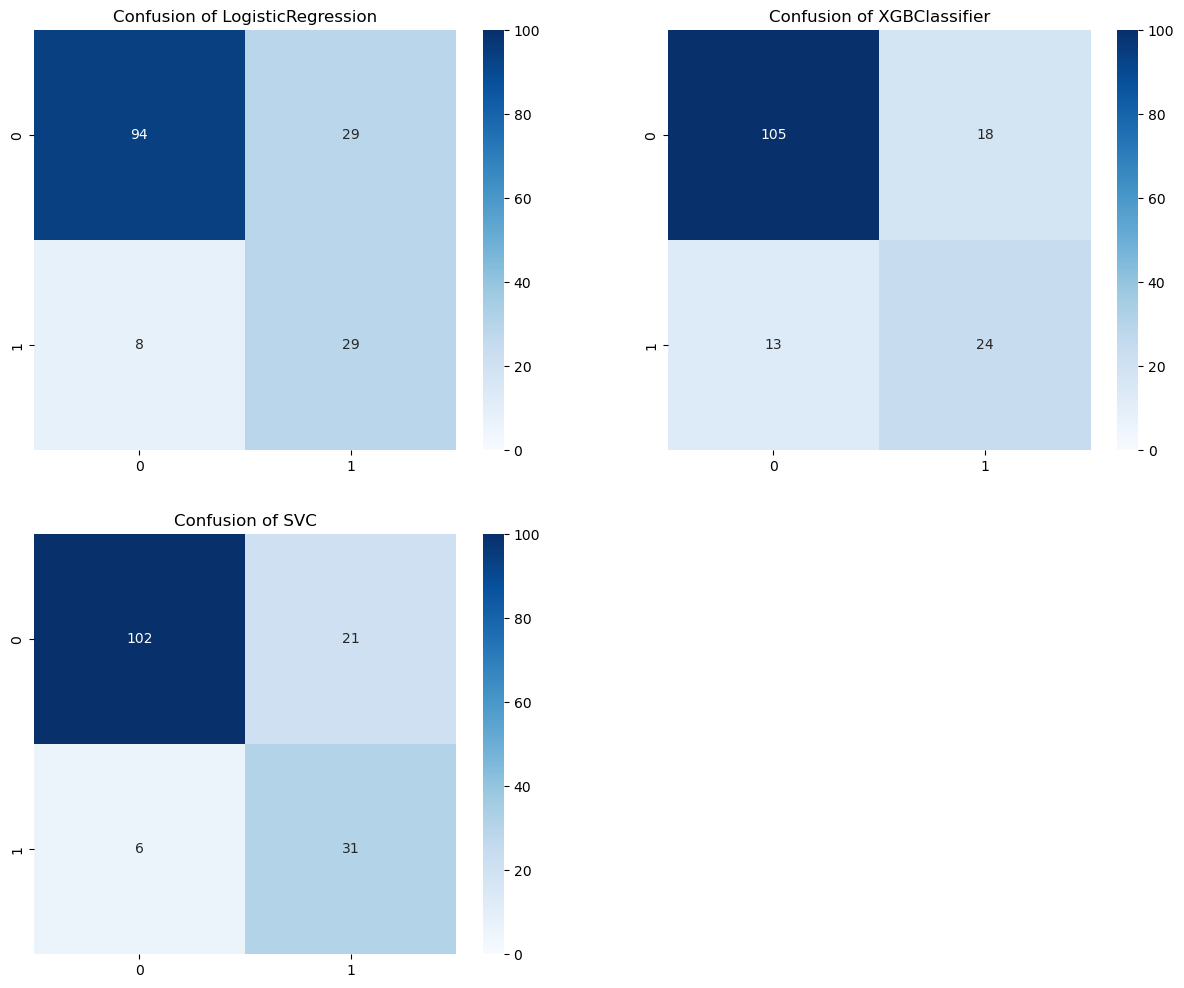

In [51]:
plt.figure(figsize=(15, 12))
for i, model in enumerate(models):
    y_pred = model.predict(X_test)
    cm = metrics.confusion_matrix(y_test, y_pred)
    plt.subplot(2, 2, i+1)
    sns.heatmap(
        cm,
        fmt='d',
        cmap=plt.cm.Blues,
        annot=True,
        vmin=0,
        vmax=100
    )
    plt.title(f'Confusion of {model.__class__.__name__}')